# Building Linear Regression from Scratch: A Mathematical Journey with SymPy

## Implementation: Step by Step

### Setting the environment

In [1]:
import sympy as sp 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

### Step 1: Define Symbolic Variables

In [2]:
sp.init_printing(use_latex="mathjax")
m, c, x, y = sp.symbols("m c x y")

IPython console for SymPy 1.13.1 (Python 3.11.14-64-bit) (ground types: gmpy)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.13.1/



### Step 2: Defining the Hypothesis in Symbolic Notation

In [3]:
hypothesis = m*x + c
print("\nStep 2: Hypothesis Formula")
sp.pprint(hypothesis)


Step 2: Hypothesis Formula
c + m*x


### Step 3: Defining the Cost Function (MSE)

In [4]:
cost_func = (hypothesis - y)**2
print("\nStep 3: Cost Function (Single Point MSE)")
sp.pprint(cost_func)


Step 3: Cost Function (Single Point MSE)
             2
(c + m*x - y) 


### Step 4: Computing Gradients with Calculus

In [5]:
# Create unevaluated derivative objects for display
grad_m_eqn = sp.Derivative(cost_func, m)
grad_c_eqn = sp.Derivative(cost_func, c)

# Calculate the actual derivative expressions 
grad_m_expr = grad_m_eqn.doit()
grad_c_expr = grad_c_eqn.doit()

print("\nStep 4: Symbolic Gradients (Calculus)", end="\n")
print("Partial Derivative for weight (m):", end="\n")

print("\n\n")
sp.pprint(grad_m_eqn)
print("Evaluates to:")
sp.pprint(grad_m_expr)

print("\nPartial Derivative for Bias (c):")

print("\n\n")
sp.pprint(grad_c_eqn)
print("Evaluates to:")
sp.pprint(grad_c_expr)


Step 4: Symbolic Gradients (Calculus)
Partial Derivative for weight (m):



d /             2\
--\(c + m*x - y) /
dm                
Evaluates to:
2*c + 2*m*x - 2*y

Partial Derivative for Bias (c):



d /             2\
--\(c + m*x - y) /
dc                
Evaluates to:
2*c + 2*m*x - 2*y


### Step 5: Loading Data with Panda

In [6]:
print("\nStep 5: Loading Data with Pandas", end="\n")
try: 
    df = pd.read_csv("/Volumes/iDrisAI/DeepLearning/Experience_Salary.csv")
    X_train = df['experience'].values
    Y_train = df['salary'].values
    print("\nData successfully loaded from CSV using Pandas.")
except FileNotFoundError:
    print("\nCSV not found")

print("X_train = ", X_train)
print("Y_train = ", Y_train)


Step 5: Loading Data with Pandas

Data successfully loaded from CSV using Pandas.
X_train =  [18.29029332 17.02340669 26.34361348 19.10583387 27.74251647 31.67117131
 14.18639863 29.932845   32.84132735 26.87386911 41.51380791 32.20117764
 34.73822584 27.51493135 25.76125817 36.92531809 23.7470025  24.09348782
 16.13380215 23.252563   25.63058204 27.59918582 22.92110427 20.05168098
 24.98304725 33.91865279 44.45485384 19.58633061 18.51115733 31.54165401
 31.71843486 18.32610619 21.34802336 26.91006992 34.93973987 27.33055795
 21.36414187 29.78202486 15.74794461 14.39682659 28.50094976 21.88009726
 10.59131485 17.12255632 36.48815058 19.5314334  34.00288198 43.27144687
 20.47647992  4.93608379 21.17397468 34.39341812 27.06220405 33.72339535
 28.63074094 25.31227406 27.33759393 18.6145     31.87655812 34.60896563
 17.06008698 25.74391561 34.15232257 20.95214793 12.01485032 12.40825677
 29.33854386 31.20573764 23.96472542  7.30476267 36.81167311 19.96209511
 46.15479158 13.9119018  28.21

### Step 6: Gradient Descent Training


In [7]:
# Compile symbolic gradients to fast numpy functions once, before training
grad_m_fn = sp.lambdify((m, c, x, y), grad_m_expr, "numpy")
grad_c_fn = sp.lambdify((m, c, x, y), grad_c_expr, "numpy")

def train_linear_regression(data_x, data_y, lr=0.01, epochs=1000):
    curr_m, curr_c = 0.0, 0.0
    n = len(data_x)
    print(f"\nStep 6: Training (LR={lr}, Epochs={epochs})....")

    for epoch in range(epochs):
        grad_m_vals = grad_m_fn(curr_m, curr_c, data_x, data_y)
        grad_c_vals = grad_c_fn(curr_m, curr_c, data_x, data_y)

        curr_m -= lr * (grad_m_vals.mean())
        curr_c -= lr * (grad_c_vals.mean())

        if epoch % 250 == 0:
            print(f" Epoch {epoch}: m = {curr_m:.4f}, c={curr_c:.4f}")
    return curr_m, curr_c

In [9]:
def evaluate_and_plot(data_x, data_y, fm, fc):
    y_true = np.array(data_y)
    y_pred = fm * data_x + fc

    # Accuracy Metrics
    r2 = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))
    mae = np.mean(np.abs(y_true - y_pred))

    print("\nStep 7: Accuracy Metrics")
    print(f"  - R² Score: {r2:.4f}")
    print(f"  - Mean Absolute Error (MAE): {mae:.4f}")

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(data_x, data_y, color='red', label='Actual Data')
    plt.plot(data_x, y_pred, color='blue', label=f'Model: y={fm:.2f}x + {fc:.2f}')
    plt.title('Linear Regression Fit (SymPy + Pandas)')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [10]:
cost_lambda = sp.lambdify((m, c, x, y), cost_func, "numpy")

def compute_total_cost(m_val, c_val, x_data, y_data):
    return np.mean(cost_lambda(m_val, c_val, x_data, y_data))



Step 6: Training (LR=0.01, Epochs=1000)...
  Epoch 0: m = 15.2294, c = 0.5345
  Epoch 250: m = 24252491467778245637840492456827927554508070092798277271661486533400589273851598994394558017297910530270020692918146696480151314861432338573358097281660262375824380905637563196309309210202319680848316479039169656172077541323969196364479217581632192366781008893874664580850388613206147858432.0000, c = 834678835495030139317322956564671129531688455677892131659885318781980296321089615927254236008881502069881221938704971476610595155036517676155308937161534768407709489770022820769569910910367625596334355931035559150419125777283332156508670427901767985364944236055049494296511549769947021312.0000
  Epoch 500: m = inf, c = inf
  Epoch 750: m = inf, c = inf

Step 7: Accuracy Metrics
  - R² Score: -inf
  - Mean Absolute Error (MAE): inf


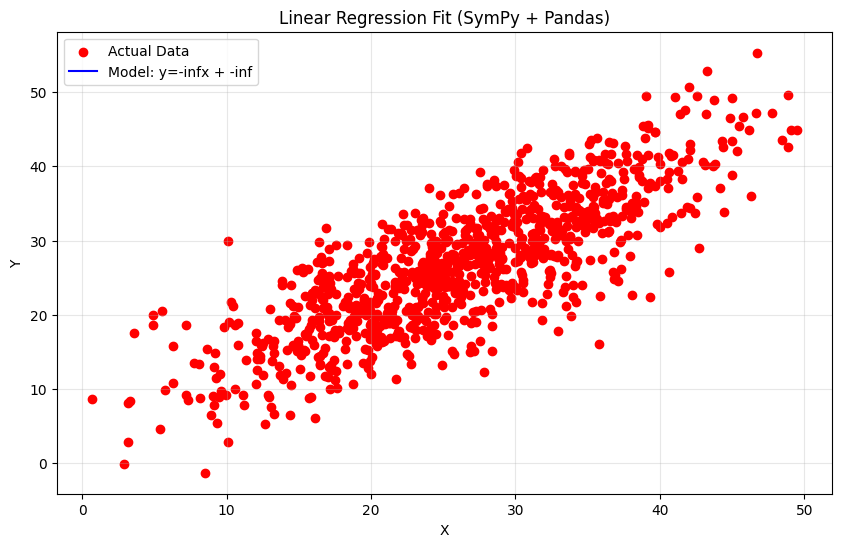

/Users/dr.idris/miniconda3/envs/deeplearning/lib/python3.11/site-packages/numpy/core/function_base.py:139: RuntimeWarning: invalid value encountered in scalar subtract
  delta = stop - start


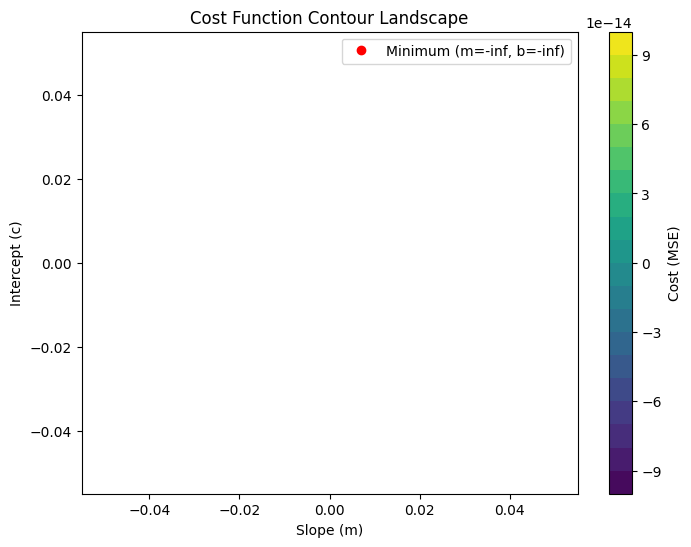

In [12]:
def plot_cost_contour(data_x, data_y, fm, fc):
    m_range = np.linspace(fm - 2, fm + 2, 50)
    c_range = np.linspace(fc - 2, fc + 2, 50)
    M, C = np.meshgrid(m_range, c_range)

    Z = np.vectorize(lambda mv, cv: compute_total_cost(mv, cv, data_x, data_y))(M, C)

    plt.figure(figsize=(8, 6))
    cp = plt.contourf(M, C, Z, levels=20, cmap="viridis")
    plt.colorbar(cp, label="Cost (MSE)")
    plt.plot(fm, fc, "ro", label=f"Minimum (m={fm:.2f}, b={fc:.2f})")
    plt.title("Cost Function Contour Landscape")
    plt.xlabel("Slope (m)")
    plt.ylabel("Intercept (c)")
    plt.legend()
    plt.show()

In [ ]:
final_m, final_c = train_linear_regression(X_train, Y_train)
evaluate_and_plot(X_train, Y_train, final_m, final_c)
plot_cost_contour(X_train, Y_train, final_m, final_c)